In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train_df = pd.read_csv("data/raw/train.csv")
store_df = pd.read_csv("data/raw/store.csv")

print(train_df.head())
print(store_df.head())

C:\Users\Soumyajit\AppData\Local\Temp\ipykernel_25948\644914776.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("data/raw/train.csv")


   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  
   Store StoreType Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0      1         c          a               1270.0                        9.0   
1      2         a          a                570.0                       11.0   
2      3         a          a              14130.0                       12.0   
3      4         c          c                620.0                        9.0   
4     

In [6]:
print("Train shape:", train_df.shape)
print("Store shape:", store_df.shape)

print("\nTrain null values:")
print(train_df.isnull().sum())

print("\nStore null values:")
print(store_df.isnull().sum())

Train shape: (1017209, 9)
Store shape: (1115, 10)

Train null values:
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Store null values:
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [7]:
df = pd.merge(train_df, store_df, on="Store", how="left")
print(df.head())
print(df.shape)

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                   

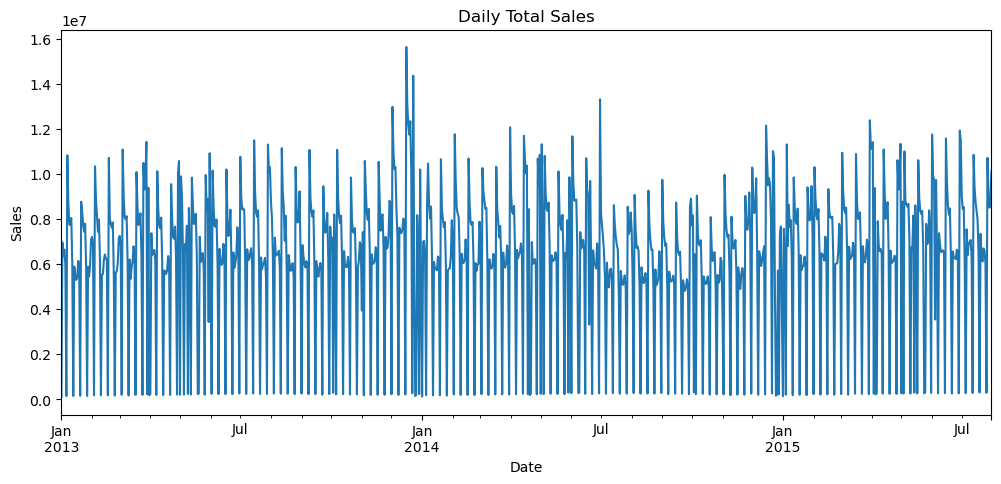

In [8]:
df["Date"] = pd.to_datetime(df["Date"])
daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Daily Total Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [9]:
promo_sales = df.groupby("Promo")["Sales"].mean()
print(promo_sales)

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64
